# Deepfake Detection System
**Author:** Sujal Dixit 

## Project Overview
This project builds an automated system to detect deepfake media (images and videos) using Deep Learning.
We leverage **Transfer Learning** with the **EfficientNetB0** architecture to identify facial artifacts that distinguish real faces from AI-generated ones.

### Key Objectives:  
1.  **Data Pipeline:** Process a large dataset of 140k real and fake faces.
2.  **Model Training:** Fine-tune a pre-trained CNN (EfficientNet) for binary classification.
3.  **Evaluation:** Analyze performance using Accuracy/Loss curves and a hold-out Test Set.
4.  **Deployment:** Build a user-friendly Web App (Gradio) for real-time video inference.

In [6]:
# 1. Standard Libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import warnings

# 2. Tensorflow & Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 3. Deployment
import gradio as gr

# Configuration
warnings.filterwarnings('ignore') # Hide messy warnings
print("Libraries Imported Successfully")

# GPU Check
if tf.config.list_physical_devices('GPU'):
    print("GPU Detected: Ready to Speed Up Training")
else:
    print("No GPU detected. Training will be slow. Check Settings.")

Libraries Imported Successfully
GPU Detected: Ready to Speed Up Training


## 1. Data Pipeline Construction
We use the `ImageDataGenerator` to load images in batches.
* **Input Shape:** (224, 224, 3) - Required for EfficientNet.
* **Pixel Values:** Raw (0-255). We do **not** rescale to 0-1 because EfficientNet includes its own internal preprocessing layer.

In [7]:
# Constants
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32
DATA_DIR = '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/'

# Data Generators
train_datagen = ImageDataGenerator()
val_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

# Load Datasets
print("Loading Training Data...")
train_generator = train_datagen.flow_from_directory(
    DATA_DIR + 'train/',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

print("\nLoading Validation Data...")
val_generator = val_datagen.flow_from_directory(
    DATA_DIR + 'valid/',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\nLoading Test Data...")
test_generator = test_datagen.flow_from_directory(
    DATA_DIR + 'test/',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Loading Training Data...
Found 100000 images belonging to 2 classes.

Loading Validation Data...
Found 20000 images belonging to 2 classes.

Loading Test Data...
Found 20000 images belonging to 2 classes.


## 2. Model Architecture (EfficientNetB0)
We employ **Transfer Learning** using the **EfficientNetB0** architecture pre-trained on ImageNet.
* **Base Model:** EfficientNetB0 (Weights frozen to preserve feature extraction capabilities).
* **Custom Head:** Added `GlobalAveragePooling2D`, a `Dense` layer (512 units), and `Dropout` (0.5) to prevent overfitting.
* **Output Layer:** Sigmoid activation (for binary classification: Real vs Fake).

In [8]:
def build_model():
    # 1. Load Pre-trained Base Model
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)
    )
    
    # 2. Freeze Base Model Weights
    base_model.trainable = False
    
    # 3. Add Custom Classification Head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)  # Prevents overfitting
    predictions = Dense(1, activation='sigmoid')(x)
    
    # 4. Compile
    model = Model(inputs=base_model.input, outputs=predictions)
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Initialize the model
model = build_model()
print("Model Built Successfully")
model.summary()

Model Built Successfully


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,705,956 (17.95 MB)

 Trainable params: 656,385 (2.50 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 3. Model Training
To optimize training time on the large dataset (140k images), we define explicit `steps_per_epoch`.
* **Callbacks:**
    * `ModelCheckpoint`: Saves the *best* version of the model (lowest validation loss).
    * `EarlyStopping`: Stops training if validation loss stops improving for 3 epochs.

In [9]:
# Configuration for Efficiency
# We use 20% of the data per epoch to speed up convergence
FAST_TRAIN_STEPS = len(train_generator) // 5
FAST_VAL_STEPS = len(val_generator) // 5

# Callbacks
checkpoint = ModelCheckpoint(
    'best_deepfake_model.keras', 
    monitor='val_loss', 
    save_best_only=True, 
    mode='min', 
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

print(f"🚀 Starting Training for 10 Epochs...")
print(f"   (Training on {FAST_TRAIN_STEPS} batches per epoch)")

history = model.fit(
    train_generator,
    steps_per_epoch=FAST_TRAIN_STEPS,
    validation_steps=FAST_VAL_STEPS,
    epochs=10,
    validation_data=val_generator,
    callbacks=[checkpoint, early_stopping]
)

print("Training Complete!")

🚀 Starting Training for 10 Epochs...
   (Training on 625 batches per epoch)
Epoch 1/10


I0000 00:00:1771416163.166844     169 service.cc:152] XLA service 0x7bd3f8216a40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771416163.166891     169 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771416163.166897     169 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771416165.392632     169 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-18 12:02:51.882582: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-18 12:02:52.026792: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-18 12:02:52.367649: E external/local_xl

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.7392 - loss: 0.5170
Epoch 1: val_loss improved from inf to 0.30321, saving model to best_deepfake_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 166s 225ms/step - accuracy: 0.7393 - loss: 0.5169 - val_accuracy: 0.8852 - val_loss: 0.3032
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.8230 - loss: 0.3990
Epoch 2: val_loss improved from 0.30321 to 0.21938, saving model to best_deepfake_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 104s 167ms/step - accuracy: 0.8230 - loss: 0.3990 - val_accuracy: 0.9287 - val_loss: 0.2194
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.8380 - loss: 0.3636
Epoch 3: val_loss did not improve from 0.21938
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 155ms/step - accuracy: 0.8380 - loss: 0.3636 - val_accuracy: 0.8500 - val_loss: 0.3502
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.8481 - loss: 0.3541
Epoch 4: val_loss did not improve from 0.21938
625/625 ━━━━━━━━━━━

## 4. Performance Visualization
We plot the **Accuracy** and **Loss** curves to diagnose model performance.
* **Good Fit:** Training and Validation lines converge (move close together).
* **Overfitting:** Training line keeps improving, but Validation line stalls or gets worse.

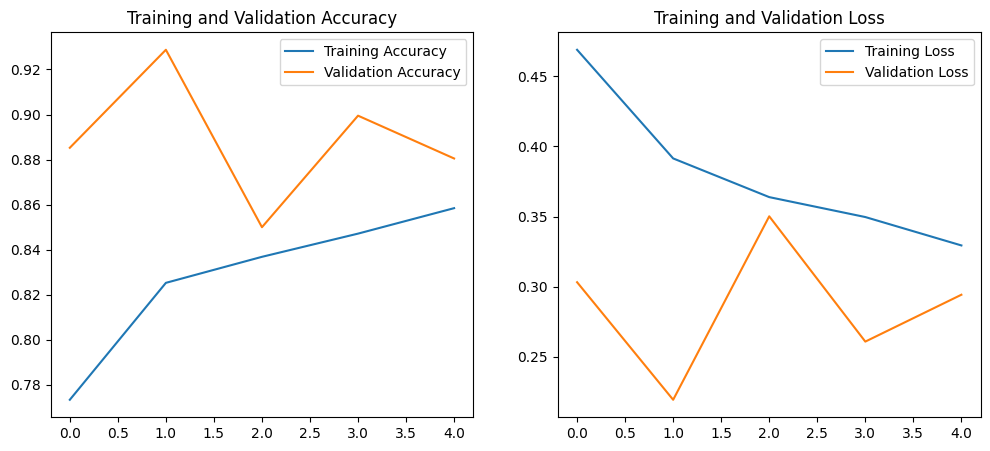

In [11]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(acc))

    plt.figure(figsize=(12, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    
    plt.show()

# Visualize the results
if 'history' in locals():
    plot_history(history)
else:
    print("Training history not found. Did the training finish?")

## 5. Test Set Evaluation
We evaluate the model on the **Test Set** (unseen data) to get the final unbiased accuracy metric.

In [12]:
# Evaluate on the Test Set
print("Evaluating on Test Data...")
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

Evaluating on Test Data...
625/625 ━━━━━━━━━━━━━━━━━━━━ 165s 264ms/step - accuracy: 0.8961 - loss: 0.2663

Final Test Accuracy: 83.82%


## 6. Save Model
We save the trained model in the Keras format (`.keras`) for deployment.

In [13]:
# Save the final model
model.save('final_deepfake_model.keras')
print("Model saved as 'final_deepfake_model.keras'")

# (Optional) Check file size
size = os.path.getsize('final_deepfake_model.keras') / (1024 * 1024)
print(f"   File Size: {size:.2f} MB")

Model saved as 'final_deepfake_model.keras'
   File Size: 23.77 MB


## 7. Deployment: Multi-Mode Deepfake Detector Interface

We utilize **Gradio** to deploy an interactive, web-based dashboard for real-time inference. The application features a **Dual-Mode Architecture** implemented via `gr.Blocks`, allowing users to switch seamlessly between Image and Video analysis.

### System Architecture:
1.  **Tab 1: Single Image Analysis**
    * **Input:** Accepts standard image formats (JPG, PNG).
    * **Preprocessing:** Automatically resizes input to `(224, 224)` and normalizes pixel values.
    * **Inference:** Expands dimensions to `(1, 224, 224, 3)` for batch processing and outputs a binary confidence score.

2.  **Tab 2: Video Sequence Analysis**
    * **Frame Extraction:** To optimize latency, the system samples video frames at a rate of **1 FPS** (Frame Per Second).
    * **Batch Processing:** Extracted frames are stacked into a tensor batch `(N_frames, 224, 224, 3)`.
    * **Temporal Aggregation:** The model predicts authenticity for every frame independently. The final verdict is derived by **averaging the confidence scores** across all frames, ensuring robust detection against fleeting artifacts.

### User Experience
* **Real-Time Feedback:** Instant "Real" vs "Fake" classification.
* **Confidence Metrics:** Displays the model's certainty percentage (e.g., "98.5% Fake").

In [ ]:
import gradio as gr
import cv2
import numpy as np
import tensorflow as tf

# --- LOGIC FOR IMAGES ---
def scan_image(image):
    if image is None:
        return "Please upload an image."
    
    # 1. Preprocess: Resize to model format (224x224)
    # Gradio provides the image as a numpy array (RGB) automatically
    img_resized = cv2.resize(image, (224, 224))
    
    # 2. Add Batch Dimension: (1, 224, 224, 3)
    img_batch = np.expand_dims(img_resized, axis=0)
    
    # 3. Predict
    prediction = model.predict(img_batch)[0][0]
    
    if prediction > 0.5:
        return f"🛑 FAKE IMAGE detected.\nConfidence: {prediction * 100:.2f}% Fake"
    else:
        return f"✅ REAL IMAGE detected.\nConfidence: {(1 - prediction) * 100:.2f}% Real"

# --- LOGIC FOR VIDEOS ---
def scan_video(video_file):
    if video_file is None:
        return "Please upload a video file."
        
    cap = cv2.VideoCapture(video_file)
    frames = []
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        # Analyze 1 frame every ~30 frames (approx. 1 second)
        if frame_count % 30 == 0:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (224, 224))
            frames.append(frame)
        frame_count += 1
    cap.release()
    
    if len(frames) == 0:
        return "Error: Could not read video."

    # Batch Prediction on all frames
    video_batch = np.array(frames)
    predictions = model.predict(video_batch)
    
    # Average the scores
    avg_score = np.mean(predictions)
    
    if avg_score > 0.5:
        return f"🛑 FAKE VIDEO detected!\nConfidence: {avg_score * 100:.2f}% Fake"
    else:
        return f"✅ REAL VIDEO detected.\nConfidence: {(1 - avg_score) * 100:.2f}% Real"

# --- THE DUAL INTERFACE (Tabs) ---
with gr.Blocks(title="🕵️‍♂️ Deepfake Detector Pro") as app:
    gr.Markdown("# 🕵️‍♂️ Deepfake Detection System")
    gr.Markdown("Select a tab below to analyze **Images** or **Videos**.")
    
    with gr.Tabs():
        # TAB 1: IMAGE
        with gr.TabItem("🖼️ Image Scanner"):
            with gr.Row():
                with gr.Column():
                    image_input = gr.Image(label="Upload Image")
                    image_button = gr.Button("Analyze Image", variant="primary")
                with gr.Column():
                    image_output = gr.Textbox(label="Result", lines=3)
            
            image_button.click(scan_image, inputs=image_input, outputs=image_output)
        
        # TAB 2: VIDEO
        with gr.TabItem("🎥 Video Scanner"):
            with gr.Row():
                with gr.Column():
                    video_input = gr.Video(label="Upload Video")
                    video_button = gr.Button("Analyze Video", variant="primary")
                with gr.Column():
                    video_output = gr.Textbox(label="Result", lines=3)
            
            video_button.click(scan_video, inputs=video_input, outputs=video_output)

# Launch
print("🚀 Launching Multi-Mode App...")
app.launch(share=True, debug=True)

🚀 Launching Multi-Mode App...
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://b3ce1d2ba438bac568.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
